## Metacell Construction (XENIUM GBM)

Computing requirements: A GPU with 16GB of RAM and disk space for your RNA and optionally ATAC data.

This notebook first computes a latent space using the SCVI method and then computes metacells, by clustering in this latent space and summing up the counts of each cluster.

You need to change the names of the directories, where your data can be found (if you don't have ATAC you can set it to None):

In [1]:
#/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new_50k.h5ad is the old one, 
# /g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new.h5ad is the new one
# NEWER the one we should work on : master_gbm_nucFiltered_scvi_leiden
# newer leidens: /g/stegle/aivazidis/data/glioma_xenium/master_min.h5ad
data_directory = "/g/stegle/aivazidis/data/glioma_xenium/"
rna_filename = "master_min.h5ad" 
atac_filename = None

Next you would need to name the keys in your anndata objects that you would like to carry over to the metacells. You can distinguish between categorical keys, such as cell types, for which the most frequent value will be assigned to each metacell and continuous keys, such as experiment time, for which the average value will be assigned to each metacell. Finally, you can also specify invariant keys, such as experiment batches, for which cells will be kept seperate and not merged into metacells:

In [ ]:
categorical_keys = ["cell_type", "leiden"]

numerical_keys = [ "transcripts",  "unique_transcripts",  "nucleus_area",   "nucleus_centroid_x",  "nucleus_centroid_y",  "cell_area", "cell_centroid_x","cell_centroid_y"]

invariant_keys = [   "sample_id",   "region",]

# Count layers to sum into metacells. These must match adata_rna.layers.keys().
# This object has layers: 'CP100' and 'nuc_raw_counts'.
#count_layer_keys = ["CP100", "nuc_raw_counts"]

Now you can run the remainder of the script as is:

In [2]:
import os
import scanpy as sc
import pandas as pd
import stormi
import numpy as np

In [4]:
file_suffix = "nn20res150" # this captures the parameters of the metacells computation function
run_SCVI = False # if you have computed the latent space before you can set this to False.
run_metacells = True

In [4]:
# Load data:
rna_path = data_directory + rna_filename
adata_rna = sc.read_h5ad(rna_path)
if atac_filename:
    atac_path = data_directory + atac_filename
    adata_atac = sc.read_h5ad(atac_path)
else:
    adata_atac = None

In [5]:
adata_rna

AnnData object with n_obs × n_vars = 1098598 × 5101
    obs: 'transcripts', 'unique_transcripts', 'nucleus_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'cell_area', 'cell_centroid_x', 'cell_centroid_y', 'batch', 'cell_id', 'slide', 'xenium_region_info', 'sample_id', 'entity', 'patient', 'region', 'patient_id', 'source', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell_type', 'sub_10', 'sub_11', 'sub_12', 'sub_17', 'sub_23', 'nested_subleiden', 'cell_type_integrated', 'leiden_raw'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_integrated_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'neighbors_scvi', 'nested_subleiden_colors', 'region_colors', 'scvi_DEG', 'subcluster_colors', 'subcluster_manual_colors', 'top100_markers', 'umap'
    obsm: 'X_pca_raw', 'X_scVI', 'X_umap', 'X_umap_raw', 'X_umap_scvi'
    layers: 'CP100', 'nuc_raw_counts'

In [ ]:
adata_rna.var_names_make_unique()
adata_rna.obs_names_make_unique() #this is the name of the cells

In [ ]:
# Run dimensionality reduction:
"""
if run_SCVI:
    from stormi.preprocessing import run_scvi
    adata_rna = run_scvi(adata_rna)
    adata_rna.write_h5ad(data_directory + rna_filename)   

"""

In [ ]:
adata_rna

In [ ]:
adata_rna.n_obs

In [ ]:
#neighbor graph
sc.pp.neighbors(adata_rna, use_rep="X_scVI", n_neighbors=20, method="umap")

#leiden at resolution ?
sc.tl.leiden(
    adata_rna,
    resolution=150,
    key_added="leiden_150",
    flavor="igraph",
    directed=False,
    n_iterations=2,
)


sizes = adata_rna.obs["leiden_150"].value_counts()
print("clusters:", len(sizes), "median:", sizes.median(), "mean:", sizes.mean(), "max:", sizes.max())

In [ ]:
count_layer_keys = ["cyto", "nuclear"]

In [ ]:
# Run metacell computation:
import importlib
import stormi.preprocessing._metacells as metacells_module

metacells_module = importlib.reload(metacells_module)
compute_metacells = metacells_module.compute_metacells
if run_metacells:
    metacells_rna = compute_metacells(
        adata_rna=adata_rna,
        adata_atac = None,
        latent_key="X_scVI",
        n_neighbors = 20,
        resolution = 150,
        numerical_keys=numerical_keys,
        merge_categorical_keys=categorical_keys,
        invariant_keys=invariant_keys,
        umap_key= "X_umap_scvi",
        leiden_key="leiden_150",
        layer_keys=count_layer_keys,
    )
    metacells_rna.write_h5ad(data_directory + 'rna_metacells_' + file_suffix + '.h5ad')
   # metacells_atac.write_h5ad(data_directory + 'atac_metacells_' + file_suffix + '.h5ad')

In [72]:
metacells_rna = sc.read_h5ad("/g/stegle/aivazidis/data/glioma_xenium/rna_metacells_leiden_23072026nn20res180.h5ad")
print("Number of metacells:", metacells_rna.n_obs)
print("Mean cells per metacell:", metacells_rna.obs["n_cells"].mean())
print("Median cells per metacell:", metacells_rna.obs["n_cells"].median())
metacells_rna.obs["n_cells"].describe()

Number of metacells: 88088
Mean cells per metacell: 12.471596585232948
Median cells per metacell: 4.0


count    88088.000000
mean        12.471597
std         26.446252
min          1.000000
25%          2.000000
50%          4.000000
75%         12.000000
max        626.000000
Name: n_cells, dtype: float64

In [4]:
metacells_rna

AnnData object with n_obs × n_vars = 88088 × 5101
    obs: 'sample_id', 'region', 'cell_type', 'leiden', 'transcripts', 'unique_transcripts', 'nucleus_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'cell_area', 'cell_centroid_x', 'cell_centroid_y', 'n_cells', 'RNA counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_180', 'leiden_colors', 'neighbors', 'neighbors_scvi', 'region_colors', 'scvi_DEG', 'top100_markers', 'umap'
    obsm: 'X_scVI', 'X_umap_scvi'
    layers: 'cyto', 'nuclear', 'spliced', 'unspliced'

In [5]:
metacells_rna.obs["n_cells"].sort_values(ascending=False).head(30)

2268_GBM_OSI44_R3_R3      626
4647_GBM_OSI43_R2_R2      603
3448_GBM_OSI27_R1_R1      592
4452_GBM_OSI44_R3_R3      589
3810_GBM_OSI44_R2_R2      563
4641_GBM_OSI43_R2_R2      557
3225_GBM_OSI46_R2_R2      517
4569_GBM_OSI44_R3_R3      516
4635_GBM_OSI43_R2_R2      513
4444_GBM_OSI37_R1_R1      505
4566_GBM_OSI27_R3_R3      485
2391_GBM_OSI44_R2_R2      485
4367_GBM_OSI43_R2_R2      483
1322_GBM_OSI28_R3_R3      464
4440_GBMh3_OSI32_R1_R1    463
2811_GBM_OSI44_R2_R2      463
3774_GBM_OSI43_R2_R2      459
4232_GBM_OSI44_R3_R3      457
3896_GBM_OSI44_R2_R2      442
2269_GBM_OSI44_R3_R3      431
2542_GBM_OSI44_R3_R3      430
4634_GBM_OSI43_R2_R2      429
4553_GBM_OSI43_R1_R1      426
3332_GBM_OSI46_R2_R2      420
1812_GBM_OSI21_R3_R3      416
4586_GBM_OSI43_R2_R2      415
4646_GBM_OSI43_R2_R2      415
3226_GBM_OSI46_R2_R2      411
4644_GBM_OSI43_R2_R2      411
1993_GBM_OSI37_R2_R2      410
Name: n_cells, dtype: int64

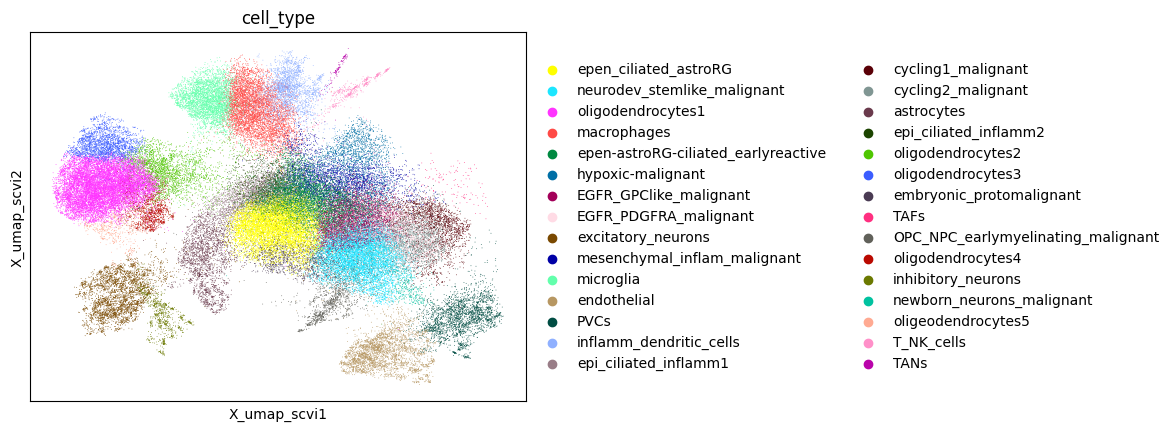

In [6]:
sc.pl.embedding(metacells_rna, basis="X_umap_scvi", color=["cell_type"])

In [ ]:
metacells_rna.obs["n_cells"].describe()

In [ ]:
metacells_rna.obs.loc[
    metacells_rna.obs["n_cells"] > 5000,
    ["n_cells", "sample_id", "region", "cell_type"]
].sort_values("n_cells", ascending=False)

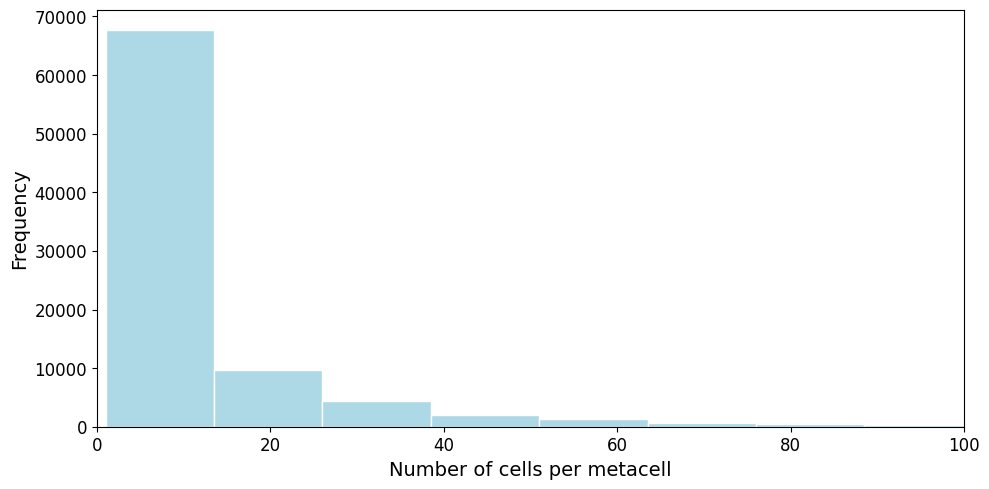

In [88]:
import scanpy as sc
import matplotlib.pyplot as plt

n_cells = metacells_rna.obs["n_cells"]

plt.figure(figsize=(10, 5))
plt.hist(n_cells, bins=50, edgecolor="white", color="lightblue")
plt.xlim(0, 100)
plt.xlabel("Number of cells per metacell", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
#plt.title("Distribution of metacell sizes", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()